In [15]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [27]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

#cfg.merge_from_file('configs/swin/maskformer2_swin_base_384_bs16_50ep.yaml')
cfg.merge_from_file('configs/panoptic_segmentation/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl'
#cfg.MODEL.WEIGHTS = './elasticdepthresnet_ckpt.pth'
#cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
cfg.MODEL.WEIGHTS = './output/model_0354999.pth'
cfg.OUTPUT_DIR = "./test_output3/"

In [28]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val_panoptic_with_sem_seg',)
  TRAIN: ('coco_2017_train_panoptic',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_panoptic_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET:

In [29]:
cfg.freeze()

In [30]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [31]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [32]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output3/
./output/model_0354999.pth


In [33]:
import cv2
im = cv2.imread("./planetopview1.png")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

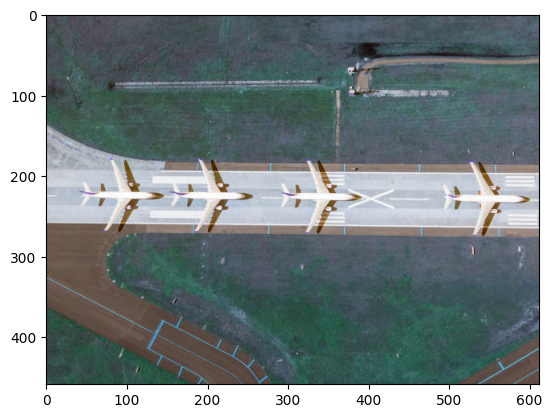

In [34]:
plt.imshow(im)

In [35]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
predictor.model.set_max_net()

#predictor.model.backbone.set_active_subnet([1,1,1,1])
outputs = predictor(im)

/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [36]:
!pwd
#print(predictor.model.backbone.layers)
all_keys = predictor.model.backbone.state_dict().keys()
#print(all_keys)
#print("layers.0.blocks.0.attn.relative_position_bias_table" in all_keys)
#print(predictor.model.backbone.layers[2].downsample)
#print(type(predictor.model.backbone.state_dict()))
#print(predictor.model.backbone.layers[2].blocks[0].attn.relative_position_bias_table.shape)
#'layers.2.blocks.0.attn.qkv.weight'
#print(predictor.model.backbone.layers[2].blocks.state_dict().keys())
#print(predictor.model)

/home/akhare39/animesh/wsobjdet


In [37]:
#torch.save(predictor.model.backbone, "ckpts/COCO_M2F_SWIN_B_InstanceSeg.pt")

In [38]:
#torch.save({"model":predictor.model.backbone.state_dict()}, "ckpts/COCO_M2F_SWIN_B_InstanceSeg_state_dict.pth")

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(550, 734, 3)


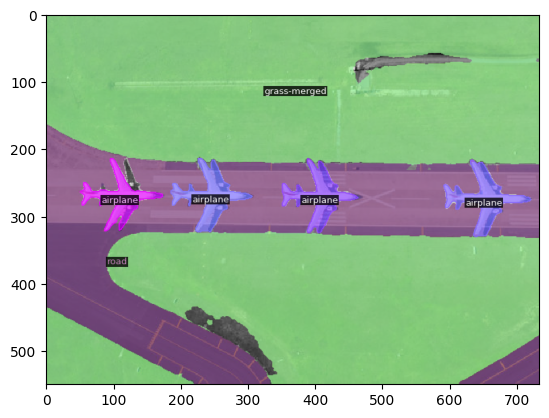

In [39]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(panoptic_result.shape)
plt.imshow(panoptic_result)

In [40]:
#!wget http://images.cocodataset.org/val2017/000000001584.jpg -q -O input.jpg
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")


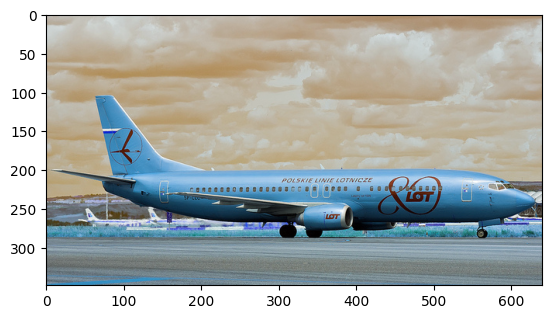

In [41]:
plt.imshow(im)

In [42]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [43]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


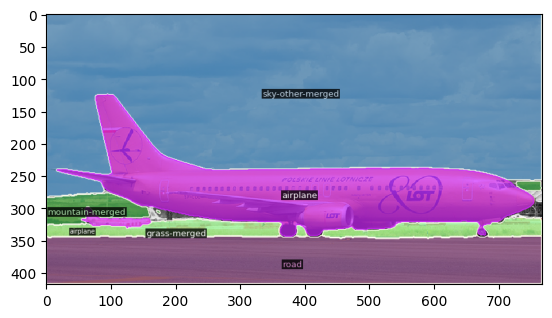

In [44]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(panoptic_result.shape)
plt.imshow(panoptic_result)

In [45]:
trainer = Trainer(cfg)

[01/08 01:26:33 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[01/08 01:26:41 d2.data.build]: Using training sampler TrainingSampler
[01/08 01:26:41 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 01:26:41 d2.data.common]: Serializing 118287 elements to byte tensors and concatenating them all ...
[01/08 01:26:42 d2.data.common]: Serialized dataset takes 78.29 MiB


In [46]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

[01/08 01:26:43 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


tensor([ 0.0129, -0.0252,  0.0189,  0.0499, -0.0133,  0.0145, -0.0045],
       device='cuda:0', grad_fn=<SliceBackward0>)
[01/08 01:26:43 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_0354999.pth ...


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

tensor([ 0.0082,  0.0090, -0.0140, -0.0188, -0.0279, -0.0262, -0.0447],
       device='cuda:0', grad_fn=<SliceBackward0>)


In [47]:
#print(model.backbone.stem.conv1.norm.weight)

In [48]:
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch


class AverageMeter(object):
    """
    Computes and stores the average and current value
    Copied from: https://github.com/pytorch/examples/blob/master/imagenet/main.py
    """

    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#both group norm and batch norm updated
def set_running_statistics(model, data_loader):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_mean[name] = AverageMeter()
            bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 2500:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [49]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [50]:
total_num_param = count_parameters(model)
print("total params", total_num_param)
          
def maskformertransformer_param_count_helper(name, param, pixel_decoder_depth, transformer_decoder_depth):
    max_pixel_depth = 6+(pixel_decoder_depth-2)-1
    max_transformer_depth = 9+(transformer_decoder_depth-2)-1
    if 'predictor' in name:
        if 'transformer_self_attention_layers' in name or 'transformer_cross_attention_layers' in name \
            or 'transformer_ffn_layers' in name:
            if int(name.split('.')[3]) <= max_transformer_depth:
                #print(name, int(name.split('.')[3]))
                return param.numel()
            else:
                return 0            
    elif 'pixel_decoder.transformer.encoder.layers' in name:
        if int(name.split('.')[5]) <= max_pixel_depth:
            #print(name, int(name.split('.')[5]))
            return param.numel()
        else:
            return 0
    return param.numel()
          
def count_parameters_small(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

def count_parameters_large(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

smallest_net_param = count_parameters_small(model, 0, 0)
print("smallest net params:", smallest_net_param)
print("precentage of total:", smallest_net_param/total_num_param)
print("percentage decrease:", (total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

middle_net_param = count_parameters_middle(model, 1, 1)
print("number of param in middle network:", middle_net_param)

smallest_backbone_param = count_parameters_small(model, 2, 2)
print("smallest backbone net params:", smallest_backbone_param)

middle_backbone_param = count_parameters_middle(model, 2, 2)
print("middle backbone net params:", middle_backbone_param)

smallest_pixel_decoder_max_rest_param = count_parameters_large(model, 0, 2)
print("max backbone, min pixel decoder, max transformer decoder net params:", smallest_pixel_decoder_max_rest_param)

smallest_transformer_decoder_max_rest_param = count_parameters_large(model, 2, 0)
print("max backbone, max pixel decoder, min transformer decoder net params:", smallest_transformer_decoder_max_rest_param)

middle_backbone_min_tf_decoder_param = count_parameters_middle(model, 2, 1)
print("middle backbone, max pixel decoder, min transformer decoder net params:", middle_backbone_min_tf_decoder_param)

total params 44036998
smallest net params: 27554630
precentage of total: 0.6257154495408611
percentage decrease: 0.37428455045913894
number of param in middle network: 35795814
smallest backbone net params: 32176518
middle backbone net params: 38106758
max backbone, min pixel decoder, max transformer decoder net params: 42572614
max backbone, max pixel decoder, min transformer decoder net params: 40879494
middle backbone, max pixel decoder, min transformer decoder net params: 36528006


In [51]:
print(model)

MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), strid

In [52]:
#train_data_loader = trainer.build_train_loader(cfg)

In [53]:
print(model.set_max_net())
print(model.backbone.runtime_depth)
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print(model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
0
0
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3


In [54]:
import warnings
warnings.filterwarnings('ignore')
print(model.sample_active_subnet())

{'backbone': {'depth_list': [2, 0, 1, 0]}, 'pixel_decoder': {'depth_list': [0]}, 'predictor': {'depth_list': [2]}}


In [55]:
#MAXIMUM NETWORK
print(model.set_max_net())
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/08 01:26:43 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 01:26:43 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 01:26:43 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 01:26:43 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 01:26:44 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 01:26:47 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0021 s/iter. Inference: 0.1741 s/iter. Eval: 0.0501 s/iter. Total: 0.2262 s/iter. ETA=0:18:48
[01/08 01:26:52 d2.evaluation.evaluator]: Inference done 34/5000. Dataloading: 0.0028 s/iter. Inference: 0.1761 s/

[01/08 01:30:18 d2.evaluation.evaluator]: Inference done 932/5000. Dataloading: 0.0029 s/iter. Inference: 0.1822 s/iter. Eval: 0.0437 s/iter. Total: 0.2289 s/iter. ETA=0:15:31
[01/08 01:30:23 d2.evaluation.evaluator]: Inference done 954/5000. Dataloading: 0.0029 s/iter. Inference: 0.1824 s/iter. Eval: 0.0436 s/iter. Total: 0.2290 s/iter. ETA=0:15:26
[01/08 01:30:28 d2.evaluation.evaluator]: Inference done 977/5000. Dataloading: 0.0029 s/iter. Inference: 0.1823 s/iter. Eval: 0.0436 s/iter. Total: 0.2289 s/iter. ETA=0:15:20
[01/08 01:30:33 d2.evaluation.evaluator]: Inference done 999/5000. Dataloading: 0.0029 s/iter. Inference: 0.1824 s/iter. Eval: 0.0434 s/iter. Total: 0.2289 s/iter. ETA=0:15:15
[01/08 01:30:38 d2.evaluation.evaluator]: Inference done 1021/5000. Dataloading: 0.0029 s/iter. Inference: 0.1823 s/iter. Eval: 0.0435 s/iter. Total: 0.2289 s/iter. ETA=0:15:10
[01/08 01:30:43 d2.evaluation.evaluator]: Inference done 1043/5000. Dataloading: 0.0029 s/iter. Inference: 0.1823 s/ite

[01/08 01:34:08 d2.evaluation.evaluator]: Inference done 1943/5000. Dataloading: 0.0029 s/iter. Inference: 0.1817 s/iter. Eval: 0.0434 s/iter. Total: 0.2281 s/iter. ETA=0:11:37
[01/08 01:34:13 d2.evaluation.evaluator]: Inference done 1966/5000. Dataloading: 0.0029 s/iter. Inference: 0.1816 s/iter. Eval: 0.0434 s/iter. Total: 0.2280 s/iter. ETA=0:11:31
[01/08 01:34:18 d2.evaluation.evaluator]: Inference done 1989/5000. Dataloading: 0.0029 s/iter. Inference: 0.1816 s/iter. Eval: 0.0434 s/iter. Total: 0.2280 s/iter. ETA=0:11:26
[01/08 01:34:23 d2.evaluation.evaluator]: Inference done 2012/5000. Dataloading: 0.0029 s/iter. Inference: 0.1815 s/iter. Eval: 0.0434 s/iter. Total: 0.2279 s/iter. ETA=0:11:20
[01/08 01:34:28 d2.evaluation.evaluator]: Inference done 2034/5000. Dataloading: 0.0029 s/iter. Inference: 0.1816 s/iter. Eval: 0.0434 s/iter. Total: 0.2280 s/iter. ETA=0:11:16
[01/08 01:34:33 d2.evaluation.evaluator]: Inference done 2056/5000. Dataloading: 0.0029 s/iter. Inference: 0.1816 s

[01/08 01:37:57 d2.evaluation.evaluator]: Inference done 2954/5000. Dataloading: 0.0029 s/iter. Inference: 0.1817 s/iter. Eval: 0.0431 s/iter. Total: 0.2278 s/iter. ETA=0:07:46
[01/08 01:38:03 d2.evaluation.evaluator]: Inference done 2977/5000. Dataloading: 0.0029 s/iter. Inference: 0.1817 s/iter. Eval: 0.0431 s/iter. Total: 0.2278 s/iter. ETA=0:07:40
[01/08 01:38:08 d2.evaluation.evaluator]: Inference done 2999/5000. Dataloading: 0.0029 s/iter. Inference: 0.1817 s/iter. Eval: 0.0431 s/iter. Total: 0.2278 s/iter. ETA=0:07:35
[01/08 01:38:13 d2.evaluation.evaluator]: Inference done 3021/5000. Dataloading: 0.0029 s/iter. Inference: 0.1818 s/iter. Eval: 0.0431 s/iter. Total: 0.2279 s/iter. ETA=0:07:30
[01/08 01:38:18 d2.evaluation.evaluator]: Inference done 3044/5000. Dataloading: 0.0029 s/iter. Inference: 0.1818 s/iter. Eval: 0.0431 s/iter. Total: 0.2279 s/iter. ETA=0:07:25
[01/08 01:38:23 d2.evaluation.evaluator]: Inference done 3067/5000. Dataloading: 0.0029 s/iter. Inference: 0.1818 s

[01/08 01:41:48 d2.evaluation.evaluator]: Inference done 3975/5000. Dataloading: 0.0030 s/iter. Inference: 0.1807 s/iter. Eval: 0.0435 s/iter. Total: 0.2273 s/iter. ETA=0:03:52
[01/08 01:41:53 d2.evaluation.evaluator]: Inference done 3998/5000. Dataloading: 0.0030 s/iter. Inference: 0.1807 s/iter. Eval: 0.0435 s/iter. Total: 0.2272 s/iter. ETA=0:03:47
[01/08 01:41:58 d2.evaluation.evaluator]: Inference done 4021/5000. Dataloading: 0.0030 s/iter. Inference: 0.1806 s/iter. Eval: 0.0435 s/iter. Total: 0.2272 s/iter. ETA=0:03:42
[01/08 01:42:03 d2.evaluation.evaluator]: Inference done 4043/5000. Dataloading: 0.0030 s/iter. Inference: 0.1806 s/iter. Eval: 0.0435 s/iter. Total: 0.2272 s/iter. ETA=0:03:37
[01/08 01:42:08 d2.evaluation.evaluator]: Inference done 4065/5000. Dataloading: 0.0030 s/iter. Inference: 0.1806 s/iter. Eval: 0.0436 s/iter. Total: 0.2273 s/iter. ETA=0:03:32
[01/08 01:42:13 d2.evaluation.evaluator]: Inference done 4087/5000. Dataloading: 0.0030 s/iter. Inference: 0.1806 s

[01/08 01:45:38 d2.evaluation.evaluator]: Inference done 4984/5000. Dataloading: 0.0030 s/iter. Inference: 0.1809 s/iter. Eval: 0.0434 s/iter. Total: 0.2274 s/iter. ETA=0:00:03
[01/08 01:45:42 d2.evaluation.evaluator]: Total inference time: 0:18:55.933070 (0.227414 s / iter per device, on 1 devices)
[01/08 01:45:42 d2.evaluation.evaluator]: Total inference pure compute time: 0:15:03 (0.180908 s / iter per device, on 1 devices)
[01/08 01:45:42 d2.evaluation.panoptic_evaluation]: Writing all panoptic predictions to /tmp/panoptic_evalfxv0h6wp ...
[01/08 01:45:51 d2.evaluation.panoptic_evaluation]: Panoptic Evaluation Results:
|        |   PQ   |   SQ   |   RQ   |  #categories  |
|:------:|:------:|:------:|:------:|:-------------:|
|  All   | 52.882 | 83.158 | 62.717 |      133      |
| Things | 58.935 | 84.211 | 69.419 |      80       |
| Stuff  | 43.747 | 81.569 | 52.600 |      53       |
[01/08 01:45:53 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[01/08 01:45:

[01/08 01:46:15 d2.evaluation.sem_seg_evaluation]: OrderedDict([('sem_seg', {'mIoU': 62.38074989884327, 'fwIoU': 70.03700335994995, 'IoU-person': 88.4571967702338, 'BoundaryIoU-person': 76.28616057257614, 'min(IoU, B-Iou)-person': 76.28616057257614, 'IoU-bicycle': 74.6712858872759, 'BoundaryIoU-bicycle': 1.2497938892994431, 'min(IoU, B-Iou)-bicycle': 1.2497938892994431, 'IoU-car': 69.04703939380423, 'BoundaryIoU-car': 0.0, 'min(IoU, B-Iou)-car': 0.0, 'IoU-motorcycle': 83.50582949573426, 'BoundaryIoU-motorcycle': 0.0, 'min(IoU, B-Iou)-motorcycle': 0.0, 'IoU-airplane': 86.13941342037714, 'BoundaryIoU-airplane': 0.0, 'min(IoU, B-Iou)-airplane': 0.0, 'IoU-bus': 84.82534281659053, 'BoundaryIoU-bus': 0.0, 'min(IoU, B-Iou)-bus': 0.0, 'IoU-train': 81.8143959515354, 'BoundaryIoU-train': 0.0, 'min(IoU, B-Iou)-train': 0.0, 'IoU-truck': 64.42100997534457, 'BoundaryIoU-truck': 0.0, 'min(IoU, B-Iou)-truck': 0.0, 'IoU-boat': 63.7354510811162, 'BoundaryIoU-boat': 0.0, 'min(IoU, B-Iou)-boat': 0.0, 'IoU

[01/08 01:46:15 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 01:46:15 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 01:46:15 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 01:46:15 d2.evaluation.testing]: copypaste: 52.8822,83.1579,62.7169,58.9346,84.2109,69.4192,43.7466,81.5685,52.6002
[01/08 01:46:15 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 01:46:15 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 01:46:15 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 01:46:15 d2.evaluation.testing]: copypaste: Task: segm
[01/08 01:46:15 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 01:46:15 d2.evaluation.testing]: copypaste: 42.8311,65.5060,45.9597,23.2699,46.5595,64.0018
[01/08 01:46:15 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 01:46:15 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [56]:
#Smallest NETWORK
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
minnet_arch = {
    'pixel_decoder': {'depth_list': [0]},
    'predictor': {'depth_list': [0]}
}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 2
transformer decoder depth 2
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/08 01:46:16 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 01:46:16 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 01:46:16 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 01:46:16 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 01:46:16 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 01:46:20 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0021 s/iter. Inference: 0.1497 s/iter. Eval: 0.0786 s/iter. Total: 0.2305 s/iter. ETA=0:19:09
[01/08 01:46:25 d2.evaluation.evaluator]: Inference done 35/5000. Dataloading: 0.0026 s/iter. Inference: 0.1504 s/iter. Eval: 0.0597 s

[01/08 01:49:49 d2.evaluation.evaluator]: Inference done 1020/5000. Dataloading: 0.0029 s/iter. Inference: 0.1585 s/iter. Eval: 0.0463 s/iter. Total: 0.2078 s/iter. ETA=0:13:46
[01/08 01:49:54 d2.evaluation.evaluator]: Inference done 1045/5000. Dataloading: 0.0029 s/iter. Inference: 0.1584 s/iter. Eval: 0.0463 s/iter. Total: 0.2077 s/iter. ETA=0:13:41
[01/08 01:49:59 d2.evaluation.evaluator]: Inference done 1071/5000. Dataloading: 0.0029 s/iter. Inference: 0.1582 s/iter. Eval: 0.0463 s/iter. Total: 0.2075 s/iter. ETA=0:13:35
[01/08 01:50:04 d2.evaluation.evaluator]: Inference done 1095/5000. Dataloading: 0.0029 s/iter. Inference: 0.1583 s/iter. Eval: 0.0463 s/iter. Total: 0.2075 s/iter. ETA=0:13:30
[01/08 01:50:09 d2.evaluation.evaluator]: Inference done 1120/5000. Dataloading: 0.0029 s/iter. Inference: 0.1582 s/iter. Eval: 0.0463 s/iter. Total: 0.2075 s/iter. ETA=0:13:24
[01/08 01:50:15 d2.evaluation.evaluator]: Inference done 1145/5000. Dataloading: 0.0029 s/iter. Inference: 0.1582 s

[01/08 01:53:39 d2.evaluation.evaluator]: Inference done 2135/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s/iter. Eval: 0.0460 s/iter. Total: 0.2071 s/iter. ETA=0:09:53
[01/08 01:53:44 d2.evaluation.evaluator]: Inference done 2160/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s/iter. Eval: 0.0461 s/iter. Total: 0.2071 s/iter. ETA=0:09:48
[01/08 01:53:50 d2.evaluation.evaluator]: Inference done 2185/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s/iter. Eval: 0.0460 s/iter. Total: 0.2071 s/iter. ETA=0:09:43
[01/08 01:53:55 d2.evaluation.evaluator]: Inference done 2210/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s/iter. Eval: 0.0460 s/iter. Total: 0.2071 s/iter. ETA=0:09:37
[01/08 01:54:00 d2.evaluation.evaluator]: Inference done 2235/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s/iter. Eval: 0.0460 s/iter. Total: 0.2070 s/iter. ETA=0:09:32
[01/08 01:54:05 d2.evaluation.evaluator]: Inference done 2261/5000. Dataloading: 0.0029 s/iter. Inference: 0.1581 s

[01/08 01:57:29 d2.evaluation.evaluator]: Inference done 3253/5000. Dataloading: 0.0029 s/iter. Inference: 0.1580 s/iter. Eval: 0.0457 s/iter. Total: 0.2067 s/iter. ETA=0:06:01
[01/08 01:57:35 d2.evaluation.evaluator]: Inference done 3278/5000. Dataloading: 0.0029 s/iter. Inference: 0.1580 s/iter. Eval: 0.0457 s/iter. Total: 0.2067 s/iter. ETA=0:05:55
[01/08 01:57:40 d2.evaluation.evaluator]: Inference done 3304/5000. Dataloading: 0.0029 s/iter. Inference: 0.1580 s/iter. Eval: 0.0457 s/iter. Total: 0.2066 s/iter. ETA=0:05:50
[01/08 01:57:45 d2.evaluation.evaluator]: Inference done 3328/5000. Dataloading: 0.0029 s/iter. Inference: 0.1579 s/iter. Eval: 0.0458 s/iter. Total: 0.2066 s/iter. ETA=0:05:45
[01/08 01:57:50 d2.evaluation.evaluator]: Inference done 3352/5000. Dataloading: 0.0029 s/iter. Inference: 0.1580 s/iter. Eval: 0.0457 s/iter. Total: 0.2067 s/iter. ETA=0:05:40
[01/08 01:57:55 d2.evaluation.evaluator]: Inference done 3377/5000. Dataloading: 0.0029 s/iter. Inference: 0.1580 s

[01/08 02:01:19 d2.evaluation.evaluator]: Inference done 4375/5000. Dataloading: 0.0029 s/iter. Inference: 0.1576 s/iter. Eval: 0.0455 s/iter. Total: 0.2061 s/iter. ETA=0:02:08
[01/08 02:01:24 d2.evaluation.evaluator]: Inference done 4397/5000. Dataloading: 0.0030 s/iter. Inference: 0.1576 s/iter. Eval: 0.0455 s/iter. Total: 0.2062 s/iter. ETA=0:02:04
[01/08 02:01:29 d2.evaluation.evaluator]: Inference done 4422/5000. Dataloading: 0.0030 s/iter. Inference: 0.1576 s/iter. Eval: 0.0455 s/iter. Total: 0.2062 s/iter. ETA=0:01:59
[01/08 02:01:34 d2.evaluation.evaluator]: Inference done 4447/5000. Dataloading: 0.0030 s/iter. Inference: 0.1576 s/iter. Eval: 0.0455 s/iter. Total: 0.2062 s/iter. ETA=0:01:54
[01/08 02:01:39 d2.evaluation.evaluator]: Inference done 4473/5000. Dataloading: 0.0030 s/iter. Inference: 0.1575 s/iter. Eval: 0.0455 s/iter. Total: 0.2061 s/iter. ETA=0:01:48
[01/08 02:01:44 d2.evaluation.evaluator]: Inference done 4498/5000. Dataloading: 0.0030 s/iter. Inference: 0.1576 s

Loading and preparing results...
DONE (t=1.38s)
creating index...
index created!
[01/08 02:03:53 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[01/08 02:04:01 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 7.75 seconds.
[01/08 02:04:01 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/08 02:04:02 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.72 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.384
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.602
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.409
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.178
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.417
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.594
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.314
 Avera

[01/08 02:04:03 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 02:04:03 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 02:04:03 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 02:04:03 d2.evaluation.testing]: copypaste: 48.7943,82.2972,58.3191,53.8602,83.0846,64.1139,41.1477,81.1088,49.5722
[01/08 02:04:03 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 02:04:03 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:04:03 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 02:04:03 d2.evaluation.testing]: copypaste: Task: segm
[01/08 02:04:03 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:04:03 d2.evaluation.testing]: copypaste: 38.4473,60.2054,40.9033,17.7813,41.7097,59.4247
[01/08 02:04:03 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 02:04:03 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [57]:
#Smallest NETWORK RESNET 50 BACKBONE max everything else
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
#model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
#model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
#minnet_arch = {
#    'pixel_decoder': {'depth_list': [0]},
#    'predictor': {'depth_list': [0]}
#}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 0
transformer decoder depth 0
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[01/08 02:04:04 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 02:04:04 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 02:04:04 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 02:04:04 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 02:04:04 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 02:04:07 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0022 s/iter. Inference: 0.1600 s/iter. Eval: 0.0728 s/iter. Total: 0.2351 s/iter. ETA=0:19:32
[01/08 02:04:13 d2.evaluation.evaluator]: Inference done 34/5000. Dataloading: 0.0027 s/iter. Inference: 0.1642 s/iter. Eval: 0.0597 s

[01/08 02:07:37 d2.evaluation.evaluator]: Inference done 958/5000. Dataloading: 0.0028 s/iter. Inference: 0.1726 s/iter. Eval: 0.0456 s/iter. Total: 0.2211 s/iter. ETA=0:14:53
[01/08 02:07:42 d2.evaluation.evaluator]: Inference done 981/5000. Dataloading: 0.0028 s/iter. Inference: 0.1726 s/iter. Eval: 0.0456 s/iter. Total: 0.2211 s/iter. ETA=0:14:48
[01/08 02:07:47 d2.evaluation.evaluator]: Inference done 1004/5000. Dataloading: 0.0029 s/iter. Inference: 0.1727 s/iter. Eval: 0.0454 s/iter. Total: 0.2211 s/iter. ETA=0:14:43
[01/08 02:07:52 d2.evaluation.evaluator]: Inference done 1028/5000. Dataloading: 0.0029 s/iter. Inference: 0.1724 s/iter. Eval: 0.0455 s/iter. Total: 0.2208 s/iter. ETA=0:14:37
[01/08 02:07:57 d2.evaluation.evaluator]: Inference done 1051/5000. Dataloading: 0.0029 s/iter. Inference: 0.1724 s/iter. Eval: 0.0455 s/iter. Total: 0.2208 s/iter. ETA=0:14:32
[01/08 02:08:02 d2.evaluation.evaluator]: Inference done 1075/5000. Dataloading: 0.0029 s/iter. Inference: 0.1723 s/i

[01/08 02:11:27 d2.evaluation.evaluator]: Inference done 2010/5000. Dataloading: 0.0028 s/iter. Inference: 0.1715 s/iter. Eval: 0.0453 s/iter. Total: 0.2197 s/iter. ETA=0:10:56
[01/08 02:11:32 d2.evaluation.evaluator]: Inference done 2033/5000. Dataloading: 0.0028 s/iter. Inference: 0.1715 s/iter. Eval: 0.0453 s/iter. Total: 0.2197 s/iter. ETA=0:10:51
[01/08 02:11:37 d2.evaluation.evaluator]: Inference done 2056/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0453 s/iter. Total: 0.2197 s/iter. ETA=0:10:46
[01/08 02:11:42 d2.evaluation.evaluator]: Inference done 2079/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0452 s/iter. Total: 0.2197 s/iter. ETA=0:10:41
[01/08 02:11:47 d2.evaluation.evaluator]: Inference done 2102/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0452 s/iter. Total: 0.2197 s/iter. ETA=0:10:36
[01/08 02:11:52 d2.evaluation.evaluator]: Inference done 2125/5000. Dataloading: 0.0028 s/iter. Inference: 0.1717 s

[01/08 02:15:16 d2.evaluation.evaluator]: Inference done 3060/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:07:05
[01/08 02:15:21 d2.evaluation.evaluator]: Inference done 3083/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:07:00
[01/08 02:15:26 d2.evaluation.evaluator]: Inference done 3106/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0448 s/iter. Total: 0.2194 s/iter. ETA=0:06:55
[01/08 02:15:31 d2.evaluation.evaluator]: Inference done 3129/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2193 s/iter. ETA=0:06:50
[01/08 02:15:36 d2.evaluation.evaluator]: Inference done 3152/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:06:45
[01/08 02:15:42 d2.evaluation.evaluator]: Inference done 3175/5000. Dataloading: 0.0028 s/iter. Inference: 0.1717 s

[01/08 02:19:06 d2.evaluation.evaluator]: Inference done 4106/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:03:16
[01/08 02:19:11 d2.evaluation.evaluator]: Inference done 4130/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2193 s/iter. ETA=0:03:10
[01/08 02:19:16 d2.evaluation.evaluator]: Inference done 4153/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2193 s/iter. ETA=0:03:05
[01/08 02:19:21 d2.evaluation.evaluator]: Inference done 4176/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:03:00
[01/08 02:19:26 d2.evaluation.evaluator]: Inference done 4198/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s/iter. Eval: 0.0449 s/iter. Total: 0.2194 s/iter. ETA=0:02:55
[01/08 02:19:31 d2.evaluation.evaluator]: Inference done 4221/5000. Dataloading: 0.0028 s/iter. Inference: 0.1716 s

[01/08 02:22:37 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.13s)
creating index...
index created!
[01/08 02:22:37 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[01/08 02:22:44 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 6.85 seconds.
[01/08 02:22:44 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/08 02:22:44 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.57 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1

[01/08 02:22:59 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 02:22:59 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 02:22:59 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 02:22:59 d2.evaluation.testing]: copypaste: 49.3224,82.6820,58.7679,54.3675,83.4214,64.5041,41.7072,81.5660,50.1096
[01/08 02:22:59 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 02:22:59 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:22:59 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 02:22:59 d2.evaluation.testing]: copypaste: Task: segm
[01/08 02:22:59 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:22:59 d2.evaluation.testing]: copypaste: 39.0536,60.9945,41.4107,18.7180,42.5946,59.7102
[01/08 02:22:59 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 02:22:59 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [58]:
#Test max backbone, max transformer decoder, min pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/08 02:22:59 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 02:22:59 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 02:22:59 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 02:22:59 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 02:23:00 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 02:23:03 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0021 s/iter. Inference: 0.1638 s/iter. Eval: 0.0582 s/iter. Total: 0.2241 s/iter. ETA=0:18:37
[01/08 02:23:08 d2.evaluation.evaluator]: Inference done 33/5000. Dataloading: 0.0027 s/iter. Inference: 0.1676 s/iter. Eval: 0.0601 s/iter. Total: 0.2304 s/iter. ETA=0:19:04
[01/08 

[01/08 02:26:32 d2.evaluation.evaluator]: Inference done 950/5000. Dataloading: 0.0028 s/iter. Inference: 0.1746 s/iter. Eval: 0.0449 s/iter. Total: 0.2223 s/iter. ETA=0:15:00
[01/08 02:26:37 d2.evaluation.evaluator]: Inference done 973/5000. Dataloading: 0.0028 s/iter. Inference: 0.1746 s/iter. Eval: 0.0448 s/iter. Total: 0.2223 s/iter. ETA=0:14:55
[01/08 02:26:42 d2.evaluation.evaluator]: Inference done 996/5000. Dataloading: 0.0028 s/iter. Inference: 0.1748 s/iter. Eval: 0.0447 s/iter. Total: 0.2224 s/iter. ETA=0:14:50
[01/08 02:26:47 d2.evaluation.evaluator]: Inference done 1020/5000. Dataloading: 0.0028 s/iter. Inference: 0.1745 s/iter. Eval: 0.0447 s/iter. Total: 0.2222 s/iter. ETA=0:14:44
[01/08 02:26:52 d2.evaluation.evaluator]: Inference done 1043/5000. Dataloading: 0.0028 s/iter. Inference: 0.1745 s/iter. Eval: 0.0448 s/iter. Total: 0.2221 s/iter. ETA=0:14:38
[01/08 02:26:57 d2.evaluation.evaluator]: Inference done 1067/5000. Dataloading: 0.0028 s/iter. Inference: 0.1743 s/it

[01/08 02:30:21 d2.evaluation.evaluator]: Inference done 1995/5000. Dataloading: 0.0028 s/iter. Inference: 0.1738 s/iter. Eval: 0.0444 s/iter. Total: 0.2211 s/iter. ETA=0:11:04
[01/08 02:30:27 d2.evaluation.evaluator]: Inference done 2019/5000. Dataloading: 0.0028 s/iter. Inference: 0.1737 s/iter. Eval: 0.0444 s/iter. Total: 0.2210 s/iter. ETA=0:10:58
[01/08 02:30:32 d2.evaluation.evaluator]: Inference done 2041/5000. Dataloading: 0.0028 s/iter. Inference: 0.1738 s/iter. Eval: 0.0444 s/iter. Total: 0.2211 s/iter. ETA=0:10:54
[01/08 02:30:37 d2.evaluation.evaluator]: Inference done 2064/5000. Dataloading: 0.0028 s/iter. Inference: 0.1738 s/iter. Eval: 0.0444 s/iter. Total: 0.2211 s/iter. ETA=0:10:49
[01/08 02:30:42 d2.evaluation.evaluator]: Inference done 2087/5000. Dataloading: 0.0028 s/iter. Inference: 0.1739 s/iter. Eval: 0.0444 s/iter. Total: 0.2211 s/iter. ETA=0:10:44
[01/08 02:30:47 d2.evaluation.evaluator]: Inference done 2110/5000. Dataloading: 0.0028 s/iter. Inference: 0.1739 s

[01/08 02:34:11 d2.evaluation.evaluator]: Inference done 3041/5000. Dataloading: 0.0028 s/iter. Inference: 0.1735 s/iter. Eval: 0.0440 s/iter. Total: 0.2205 s/iter. ETA=0:07:11
[01/08 02:34:16 d2.evaluation.evaluator]: Inference done 3064/5000. Dataloading: 0.0028 s/iter. Inference: 0.1736 s/iter. Eval: 0.0440 s/iter. Total: 0.2205 s/iter. ETA=0:07:06
[01/08 02:34:21 d2.evaluation.evaluator]: Inference done 3087/5000. Dataloading: 0.0028 s/iter. Inference: 0.1735 s/iter. Eval: 0.0440 s/iter. Total: 0.2205 s/iter. ETA=0:07:01
[01/08 02:34:26 d2.evaluation.evaluator]: Inference done 3108/5000. Dataloading: 0.0028 s/iter. Inference: 0.1736 s/iter. Eval: 0.0442 s/iter. Total: 0.2206 s/iter. ETA=0:06:57
[01/08 02:34:31 d2.evaluation.evaluator]: Inference done 3131/5000. Dataloading: 0.0028 s/iter. Inference: 0.1735 s/iter. Eval: 0.0442 s/iter. Total: 0.2206 s/iter. ETA=0:06:52
[01/08 02:34:36 d2.evaluation.evaluator]: Inference done 3154/5000. Dataloading: 0.0028 s/iter. Inference: 0.1735 s

[01/08 02:38:01 d2.evaluation.evaluator]: Inference done 4090/5000. Dataloading: 0.0028 s/iter. Inference: 0.1732 s/iter. Eval: 0.0441 s/iter. Total: 0.2202 s/iter. ETA=0:03:20
[01/08 02:38:06 d2.evaluation.evaluator]: Inference done 4113/5000. Dataloading: 0.0028 s/iter. Inference: 0.1733 s/iter. Eval: 0.0441 s/iter. Total: 0.2202 s/iter. ETA=0:03:15
[01/08 02:38:11 d2.evaluation.evaluator]: Inference done 4137/5000. Dataloading: 0.0028 s/iter. Inference: 0.1733 s/iter. Eval: 0.0440 s/iter. Total: 0.2202 s/iter. ETA=0:03:10
[01/08 02:38:16 d2.evaluation.evaluator]: Inference done 4160/5000. Dataloading: 0.0028 s/iter. Inference: 0.1732 s/iter. Eval: 0.0441 s/iter. Total: 0.2202 s/iter. ETA=0:03:04
[01/08 02:38:22 d2.evaluation.evaluator]: Inference done 4183/5000. Dataloading: 0.0028 s/iter. Inference: 0.1733 s/iter. Eval: 0.0441 s/iter. Total: 0.2202 s/iter. ETA=0:02:59
[01/08 02:38:27 d2.evaluation.evaluator]: Inference done 4206/5000. Dataloading: 0.0028 s/iter. Inference: 0.1733 s

[01/08 02:41:35 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[01/08 02:41:35 d2.evaluation.coco_evaluation]: Saving results to ./test_output3/inference/coco_instances_results.json
[01/08 02:41:35 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.12s)
creating index...
index created!
[01/08 02:41:36 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[01/08 02:41:42 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 6.88 seconds.
[01/08 02:41:43 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/08 02:41:43 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.54 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (A

[01/08 02:41:57 d2.evaluation.sem_seg_evaluation]: OrderedDict([('sem_seg', {'mIoU': 61.90730687321546, 'fwIoU': 69.77657922727364, 'IoU-person': 88.24898049008014, 'BoundaryIoU-person': 76.0804650726607, 'min(IoU, B-Iou)-person': 76.0804650726607, 'IoU-bicycle': 75.28421779278563, 'BoundaryIoU-bicycle': 1.2467302030597092, 'min(IoU, B-Iou)-bicycle': 1.2467302030597092, 'IoU-car': 67.47335804124303, 'BoundaryIoU-car': 0.0, 'min(IoU, B-Iou)-car': 0.0, 'IoU-motorcycle': 83.07635287415364, 'BoundaryIoU-motorcycle': 0.0, 'min(IoU, B-Iou)-motorcycle': 0.0, 'IoU-airplane': 86.02678218257338, 'BoundaryIoU-airplane': 0.0, 'min(IoU, B-Iou)-airplane': 0.0, 'IoU-bus': 85.79777720712669, 'BoundaryIoU-bus': 0.0, 'min(IoU, B-Iou)-bus': 0.0, 'IoU-train': 82.29339789032718, 'BoundaryIoU-train': 0.0, 'min(IoU, B-Iou)-train': 0.0, 'IoU-truck': 62.09739270954555, 'BoundaryIoU-truck': 0.0, 'min(IoU, B-Iou)-truck': 0.0, 'IoU-boat': 64.38696790152989, 'BoundaryIoU-boat': 0.0, 'min(IoU, B-Iou)-boat': 0.0, 'I

[01/08 02:41:57 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 02:41:57 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 02:41:57 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 02:41:57 d2.evaluation.testing]: copypaste: 52.2279,82.9957,62.0556,58.2270,84.0118,68.7162,43.1727,81.4619,52.0018
[01/08 02:41:57 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 02:41:57 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:41:57 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 02:41:57 d2.evaluation.testing]: copypaste: Task: segm
[01/08 02:41:57 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 02:41:57 d2.evaluation.testing]: copypaste: 42.2550,64.7334,45.2074,22.4317,45.9562,63.2608
[01/08 02:41:57 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 02:41:57 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [59]:
#Test max backbone, min transformer decoder, max pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
model.sem_seg_head.pixel_decoder.transformer.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[01/08 02:41:58 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 02:41:58 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 02:41:58 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 02:41:58 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 02:41:58 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 02:42:01 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0022 s/iter. Inference: 0.1705 s/iter. Eval: 0.0666 s/iter. Total: 0.2394 s/iter. ETA=0:19:54
[01/08 02:42:06 d2.evaluation.evaluator]: Inference done 33/5000. Dataloading: 0.0026 s/iter. Inference: 0.1706 s/iter. Eval: 0.0600 s/iter. Total: 0.2333 s/iter. ETA=0:19:18
[01/08 

[01/08 02:45:31 d2.evaluation.evaluator]: Inference done 946/5000. Dataloading: 0.0029 s/iter. Inference: 0.1768 s/iter. Eval: 0.0446 s/iter. Total: 0.2244 s/iter. ETA=0:15:09
[01/08 02:45:36 d2.evaluation.evaluator]: Inference done 968/5000. Dataloading: 0.0029 s/iter. Inference: 0.1770 s/iter. Eval: 0.0445 s/iter. Total: 0.2245 s/iter. ETA=0:15:05
[01/08 02:45:41 d2.evaluation.evaluator]: Inference done 991/5000. Dataloading: 0.0029 s/iter. Inference: 0.1770 s/iter. Eval: 0.0445 s/iter. Total: 0.2244 s/iter. ETA=0:14:59
[01/08 02:45:46 d2.evaluation.evaluator]: Inference done 1014/5000. Dataloading: 0.0029 s/iter. Inference: 0.1770 s/iter. Eval: 0.0444 s/iter. Total: 0.2243 s/iter. ETA=0:14:54
[01/08 02:45:51 d2.evaluation.evaluator]: Inference done 1038/5000. Dataloading: 0.0029 s/iter. Inference: 0.1767 s/iter. Eval: 0.0444 s/iter. Total: 0.2241 s/iter. ETA=0:14:47
[01/08 02:45:56 d2.evaluation.evaluator]: Inference done 1061/5000. Dataloading: 0.0029 s/iter. Inference: 0.1767 s/it

[01/08 02:49:22 d2.evaluation.evaluator]: Inference done 1992/5000. Dataloading: 0.0028 s/iter. Inference: 0.1754 s/iter. Eval: 0.0441 s/iter. Total: 0.2224 s/iter. ETA=0:11:09
[01/08 02:49:27 d2.evaluation.evaluator]: Inference done 2015/5000. Dataloading: 0.0028 s/iter. Inference: 0.1754 s/iter. Eval: 0.0441 s/iter. Total: 0.2224 s/iter. ETA=0:11:03
[01/08 02:49:32 d2.evaluation.evaluator]: Inference done 2038/5000. Dataloading: 0.0028 s/iter. Inference: 0.1755 s/iter. Eval: 0.0441 s/iter. Total: 0.2224 s/iter. ETA=0:10:58
[01/08 02:49:37 d2.evaluation.evaluator]: Inference done 2061/5000. Dataloading: 0.0028 s/iter. Inference: 0.1755 s/iter. Eval: 0.0441 s/iter. Total: 0.2224 s/iter. ETA=0:10:53
[01/08 02:49:42 d2.evaluation.evaluator]: Inference done 2084/5000. Dataloading: 0.0028 s/iter. Inference: 0.1755 s/iter. Eval: 0.0440 s/iter. Total: 0.2225 s/iter. ETA=0:10:48
[01/08 02:49:48 d2.evaluation.evaluator]: Inference done 2107/5000. Dataloading: 0.0028 s/iter. Inference: 0.1756 s

[01/08 02:53:11 d2.evaluation.evaluator]: Inference done 3037/5000. Dataloading: 0.0028 s/iter. Inference: 0.1750 s/iter. Eval: 0.0436 s/iter. Total: 0.2214 s/iter. ETA=0:07:14
[01/08 02:53:16 d2.evaluation.evaluator]: Inference done 3060/5000. Dataloading: 0.0028 s/iter. Inference: 0.1750 s/iter. Eval: 0.0436 s/iter. Total: 0.2214 s/iter. ETA=0:07:09
[01/08 02:53:21 d2.evaluation.evaluator]: Inference done 3083/5000. Dataloading: 0.0028 s/iter. Inference: 0.1750 s/iter. Eval: 0.0436 s/iter. Total: 0.2214 s/iter. ETA=0:07:04
[01/08 02:53:26 d2.evaluation.evaluator]: Inference done 3106/5000. Dataloading: 0.0028 s/iter. Inference: 0.1750 s/iter. Eval: 0.0435 s/iter. Total: 0.2214 s/iter. ETA=0:06:59
[01/08 02:53:32 d2.evaluation.evaluator]: Inference done 3130/5000. Dataloading: 0.0028 s/iter. Inference: 0.1749 s/iter. Eval: 0.0436 s/iter. Total: 0.2214 s/iter. ETA=0:06:53
[01/08 02:53:37 d2.evaluation.evaluator]: Inference done 3153/5000. Dataloading: 0.0028 s/iter. Inference: 0.1750 s

[01/08 02:57:01 d2.evaluation.evaluator]: Inference done 4083/5000. Dataloading: 0.0028 s/iter. Inference: 0.1745 s/iter. Eval: 0.0436 s/iter. Total: 0.2210 s/iter. ETA=0:03:22
[01/08 02:57:06 d2.evaluation.evaluator]: Inference done 4106/5000. Dataloading: 0.0028 s/iter. Inference: 0.1745 s/iter. Eval: 0.0436 s/iter. Total: 0.2210 s/iter. ETA=0:03:17
[01/08 02:57:11 d2.evaluation.evaluator]: Inference done 4129/5000. Dataloading: 0.0028 s/iter. Inference: 0.1746 s/iter. Eval: 0.0436 s/iter. Total: 0.2211 s/iter. ETA=0:03:12
[01/08 02:57:16 d2.evaluation.evaluator]: Inference done 4152/5000. Dataloading: 0.0028 s/iter. Inference: 0.1746 s/iter. Eval: 0.0436 s/iter. Total: 0.2210 s/iter. ETA=0:03:07
[01/08 02:57:22 d2.evaluation.evaluator]: Inference done 4175/5000. Dataloading: 0.0028 s/iter. Inference: 0.1745 s/iter. Eval: 0.0436 s/iter. Total: 0.2211 s/iter. ETA=0:03:02
[01/08 02:57:27 d2.evaluation.evaluator]: Inference done 4197/5000. Dataloading: 0.0028 s/iter. Inference: 0.1746 s

[01/08 03:00:37 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[01/08 03:00:37 d2.evaluation.coco_evaluation]: Saving results to ./test_output3/inference/coco_instances_results.json
[01/08 03:00:37 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.13s)
creating index...
index created!
[01/08 03:00:38 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[01/08 03:00:45 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 6.98 seconds.
[01/08 03:00:45 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[01/08 03:00:45 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 0.55 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (A

[01/08 03:01:00 d2.evaluation.sem_seg_evaluation]: OrderedDict([('sem_seg', {'mIoU': 62.38411043253793, 'fwIoU': 70.11628604935613, 'IoU-person': 88.44106911410259, 'BoundaryIoU-person': 76.32248811429724, 'min(IoU, B-Iou)-person': 76.32248811429724, 'IoU-bicycle': 74.44995802657634, 'BoundaryIoU-bicycle': 1.2473085470558989, 'min(IoU, B-Iou)-bicycle': 1.2473085470558989, 'IoU-car': 69.37835916986216, 'BoundaryIoU-car': 0.0, 'min(IoU, B-Iou)-car': 0.0, 'IoU-motorcycle': 83.37944892153737, 'BoundaryIoU-motorcycle': 0.0, 'min(IoU, B-Iou)-motorcycle': 0.0, 'IoU-airplane': 85.56260871117965, 'BoundaryIoU-airplane': 0.0, 'min(IoU, B-Iou)-airplane': 0.0, 'IoU-bus': 85.77650991748115, 'BoundaryIoU-bus': 0.0, 'min(IoU, B-Iou)-bus': 0.0, 'IoU-train': 83.20609441993956, 'BoundaryIoU-train': 0.0, 'min(IoU, B-Iou)-train': 0.0, 'IoU-truck': 63.220921581873945, 'BoundaryIoU-truck': 0.0, 'min(IoU, B-Iou)-truck': 0.0, 'IoU-boat': 64.48425727847824, 'BoundaryIoU-boat': 0.0, 'min(IoU, B-Iou)-boat': 0.0,

[01/08 03:01:00 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 03:01:00 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 03:01:00 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 03:01:00 d2.evaluation.testing]: copypaste: 52.9281,83.1062,62.8138,58.9551,84.1811,69.4716,43.8307,81.4837,52.7643
[01/08 03:01:00 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 03:01:00 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 03:01:00 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 03:01:00 d2.evaluation.testing]: copypaste: Task: segm
[01/08 03:01:00 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 03:01:00 d2.evaluation.testing]: copypaste: 42.7906,65.4689,45.9043,23.7151,46.4828,64.3292
[01/08 03:01:00 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 03:01:00 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [60]:
#Test middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([1])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([1])

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
1
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/08 03:01:00 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 03:01:00 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 03:01:00 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 03:01:00 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 03:01:00 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 03:01:04 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0021 s/iter. Inference: 0.1619 s/iter. Eval: 0.0918 s/iter. Total: 0.2559 s/iter. ETA=0:21:16
[01/08 03:01:09 d2.evaluation.evaluator]: Inference done 34/5000. Dataloading: 0.0028 s/iter. Inference: 0.1642 s/iter. Eval: 0.0641 s/iter. Total: 0.2312 s/iter. ETA=0:19:08
[01/08 

[01/08 03:04:33 d2.evaluation.evaluator]: Inference done 970/5000. Dataloading: 0.0029 s/iter. Inference: 0.1703 s/iter. Eval: 0.0453 s/iter. Total: 0.2185 s/iter. ETA=0:14:40
[01/08 03:04:38 d2.evaluation.evaluator]: Inference done 993/5000. Dataloading: 0.0029 s/iter. Inference: 0.1704 s/iter. Eval: 0.0452 s/iter. Total: 0.2185 s/iter. ETA=0:14:35
[01/08 03:04:43 d2.evaluation.evaluator]: Inference done 1017/5000. Dataloading: 0.0029 s/iter. Inference: 0.1702 s/iter. Eval: 0.0451 s/iter. Total: 0.2183 s/iter. ETA=0:14:29
[01/08 03:04:49 d2.evaluation.evaluator]: Inference done 1041/5000. Dataloading: 0.0029 s/iter. Inference: 0.1701 s/iter. Eval: 0.0452 s/iter. Total: 0.2182 s/iter. ETA=0:14:23
[01/08 03:04:54 d2.evaluation.evaluator]: Inference done 1065/5000. Dataloading: 0.0029 s/iter. Inference: 0.1699 s/iter. Eval: 0.0452 s/iter. Total: 0.2181 s/iter. ETA=0:14:18
[01/08 03:04:59 d2.evaluation.evaluator]: Inference done 1088/5000. Dataloading: 0.0029 s/iter. Inference: 0.1699 s/i

[01/08 03:08:22 d2.evaluation.evaluator]: Inference done 2039/5000. Dataloading: 0.0028 s/iter. Inference: 0.1684 s/iter. Eval: 0.0449 s/iter. Total: 0.2163 s/iter. ETA=0:10:40
[01/08 03:08:27 d2.evaluation.evaluator]: Inference done 2063/5000. Dataloading: 0.0028 s/iter. Inference: 0.1685 s/iter. Eval: 0.0449 s/iter. Total: 0.2162 s/iter. ETA=0:10:35
[01/08 03:08:32 d2.evaluation.evaluator]: Inference done 2086/5000. Dataloading: 0.0028 s/iter. Inference: 0.1685 s/iter. Eval: 0.0449 s/iter. Total: 0.2163 s/iter. ETA=0:10:30
[01/08 03:08:38 d2.evaluation.evaluator]: Inference done 2107/5000. Dataloading: 0.0028 s/iter. Inference: 0.1689 s/iter. Eval: 0.0448 s/iter. Total: 0.2166 s/iter. ETA=0:10:26
[01/08 03:08:43 d2.evaluation.evaluator]: Inference done 2131/5000. Dataloading: 0.0028 s/iter. Inference: 0.1689 s/iter. Eval: 0.0447 s/iter. Total: 0.2166 s/iter. ETA=0:10:21
[01/08 03:08:48 d2.evaluation.evaluator]: Inference done 2155/5000. Dataloading: 0.0028 s/iter. Inference: 0.1689 s

[01/08 03:12:13 d2.evaluation.evaluator]: Inference done 3107/5000. Dataloading: 0.0028 s/iter. Inference: 0.1687 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:06:48
[01/08 03:12:18 d2.evaluation.evaluator]: Inference done 3131/5000. Dataloading: 0.0028 s/iter. Inference: 0.1687 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:06:43
[01/08 03:12:23 d2.evaluation.evaluator]: Inference done 3155/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:06:38
[01/08 03:12:28 d2.evaluation.evaluator]: Inference done 3178/5000. Dataloading: 0.0028 s/iter. Inference: 0.1687 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:06:33
[01/08 03:12:33 d2.evaluation.evaluator]: Inference done 3202/5000. Dataloading: 0.0028 s/iter. Inference: 0.1687 s/iter. Eval: 0.0444 s/iter. Total: 0.2160 s/iter. ETA=0:06:28
[01/08 03:12:38 d2.evaluation.evaluator]: Inference done 3225/5000. Dataloading: 0.0028 s/iter. Inference: 0.1687 s

[01/08 03:16:03 d2.evaluation.evaluator]: Inference done 4174/5000. Dataloading: 0.0028 s/iter. Inference: 0.1685 s/iter. Eval: 0.0446 s/iter. Total: 0.2160 s/iter. ETA=0:02:58
[01/08 03:16:08 d2.evaluation.evaluator]: Inference done 4196/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s/iter. Eval: 0.0445 s/iter. Total: 0.2161 s/iter. ETA=0:02:53
[01/08 03:16:13 d2.evaluation.evaluator]: Inference done 4220/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s/iter. Eval: 0.0445 s/iter. Total: 0.2161 s/iter. ETA=0:02:48
[01/08 03:16:18 d2.evaluation.evaluator]: Inference done 4244/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:02:43
[01/08 03:16:23 d2.evaluation.evaluator]: Inference done 4268/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s/iter. Eval: 0.0445 s/iter. Total: 0.2160 s/iter. ETA=0:02:38
[01/08 03:16:29 d2.evaluation.evaluator]: Inference done 4292/5000. Dataloading: 0.0028 s/iter. Inference: 0.1686 s

[01/08 03:19:22 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

[01/08 03:19:35 d2.engine.defaults]: Evaluation results for coco_2017_val_panoptic_with_sem_seg in csv format:
[01/08 03:19:35 d2.evaluation.testing]: copypaste: Task: panoptic_seg
[01/08 03:19:35 d2.evaluation.testing]: copypaste: PQ,SQ,RQ,PQ_th,SQ_th,RQ_th,PQ_st,SQ_st,RQ_st
[01/08 03:19:35 d2.evaluation.testing]: copypaste: 51.7844,82.9931,61.5881,57.4552,83.8843,67.9227,43.2248,81.6479,52.0264
[01/08 03:19:35 d2.evaluation.testing]: copypaste: Task: bbox
[01/08 03:19:35 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 03:19:35 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[01/08 03:19:35 d2.evaluation.testing]: copypaste: Task: segm
[01/08 03:19:35 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[01/08 03:19:35 d2.evaluation.testing]: copypaste: 41.4892,64.0074,44.2840,21.2498,45.3395,62.2753
[01/08 03:19:35 d2.evaluation.testing]: copypaste: Task: sem_seg
[01/08 03:19:35 d2.evaluation.testing]: copypaste: mIoU,fwIoU,mACC,

In [61]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [ ]:
#Test middle resnet, min decoder max pixel decoder
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([2])
#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
2
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[01/08 03:19:36 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/08 03:19:36 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/08 03:19:36 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[01/08 03:19:36 d2.data.common]: Serialized dataset takes 3.68 MiB
[01/08 03:19:37 d2.evaluation.evaluator]: Start inference on 5000 batches
[01/08 03:19:40 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0020 s/iter. Inference: 0.1611 s/iter. Eval: 0.0723 s/iter. Total: 0.2354 s/iter. ETA=0:19:34
[01/08 03:19:45 d2.evaluation.evaluator]: Inference done 32/5000. Dataloading: 0.0028 s/iter. Inference: 0.1841 s/iter. Eval: 0.0558 s/iter. Total: 0.2428 s/iter. ETA=0:20:06
[01/08 

[01/08 03:23:09 d2.evaluation.evaluator]: Inference done 964/5000. Dataloading: 0.0028 s/iter. Inference: 0.1715 s/iter. Eval: 0.0452 s/iter. Total: 0.2196 s/iter. ETA=0:14:46
[01/08 03:23:14 d2.evaluation.evaluator]: Inference done 988/5000. Dataloading: 0.0028 s/iter. Inference: 0.1714 s/iter. Eval: 0.0452 s/iter. Total: 0.2195 s/iter. ETA=0:14:40
[01/08 03:23:20 d2.evaluation.evaluator]: Inference done 1012/5000. Dataloading: 0.0028 s/iter. Inference: 0.1715 s/iter. Eval: 0.0450 s/iter. Total: 0.2194 s/iter. ETA=0:14:34
[01/08 03:23:25 d2.evaluation.evaluator]: Inference done 1036/5000. Dataloading: 0.0028 s/iter. Inference: 0.1712 s/iter. Eval: 0.0451 s/iter. Total: 0.2192 s/iter. ETA=0:14:29
[01/08 03:23:30 d2.evaluation.evaluator]: Inference done 1059/5000. Dataloading: 0.0028 s/iter. Inference: 0.1713 s/iter. Eval: 0.0451 s/iter. Total: 0.2192 s/iter. ETA=0:14:23
[01/08 03:23:35 d2.evaluation.evaluator]: Inference done 1083/5000. Dataloading: 0.0028 s/iter. Inference: 0.1712 s/i

In [ ]:
#Test resnet middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_max_net()

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

In [ ]:
print(cfg)

In [ ]:
print(model.backbone.sample_active_subnet())
print(model.sample_active_subnet())
print(model.set_max_net())

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
#predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
predictor.model.sem_seg_head.predictor.set_active_subnet([0])
print(predictor.model.sem_seg_head.predictor.runtime_depth)
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
print(model.backbone.stem.conv1.norm.weight)